棋局复杂度与棋手失误类型的关系

# Complexity 高低 → Blunder / Mistake 发生概率

In [3]:
import pandas as pd
import json
import ast

csv_path=r"C:\Users\Administrator\Desktop\Chess\data\input\complex.csv"
df=pd.read_csv(csv_path)

In [4]:
df.head()

,row_idx,White,Black,White CP Loss,White Accuracy,Black CP Loss,Black Accuracy,Stage Analysis,Evaluation,Judgments,...,White Inaccuracies,Black Blunders,Black Mistakes,Black Inaccuracies,Complexity E1,Complexity E2,Complexity P,Complexity S,White Complexity Sum,Black Complexity Sum
0,127214,Teodora Injac,Josefine Heinemann,47.571429,81.479751,27.171429,87.306038,{'beginning': {'white': {'accuracy': 97.074174...,"0.20,0.21,0.19,0.26,0.26,0.25,0.23,0.25,0.21,0...","-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,...",...,4,1,1,1,"32,-20,21,-19,26,-26,25,-23,25,-21,18,-12,26,1...","23,-21,13,-27,25,-28,2,-24,22,-21,15,-18,18,-2...","0.711,0.525,0.690,0.690,0.525,0.550,0.909,0.52...","0.492,0.930,0.535,0.535,0.930,0.863,0.138,0.93...",15.154733,10.788352
1,127215,Mauri Lehtosaari,Jose Garcia Molina,44.441176,84.751150,28.382353,91.294191,{'beginning': {'white': {'accuracy': 97.025433...,"0.22,0.28,0.24,0.25,0.15,0.13,0.02,0.11,-0.25,...","-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,...",...,3,0,2,2,"27,-22,28,-24,25,-15,13,-2,11,25,-26,22,-3,1,-...","25,-30,27,-26,17,-17,10,-587,-7,12,-27,15,-3,-...","0.550,0.690,0.525,0.550,0.690,0.550,0.574,1.00...","0.863,0.535,0.930,0.863,0.535,0.863,0.800,-0.0...",15.719362,11.608778
2,127216,Lazaro Lorenzo De La Riva,Luisa Bashylina,33.837838,86.467746,56.194444,82.286900,{'beginning': {'white': {'accuracy': 85.555278...,"0.20,0.64,0.11,0.33,0.22,0.24,0.27,0.41,0.33,1...","-,-,-,-,-,-,-,-,-,Inaccuracy,Inaccuracy,-,Inac...",...,5,1,1,6,"21,-20,64,-11,33,-22,24,-27,41,-33,140,-68,90,...","17,-23,51,-33,32,-25,24,-28,26,-42,65,-214,88,...","0.599,0.574,0.786,0.900,0.525,0.574,0.500,0.52...","0.740,0.800,0.348,0.152,0.930,0.800,1.000,0.93...",12.006086,14.033451
3,127217,Mukhiddin Madaminov,Aleksa Micic,22.057143,90.078757,40.735294,83.533783,{'beginning': {'white': {'accuracy': 94.158590...,"0.23,0.24,-0.06,0.01,0.03,0.05,0.04,0.08,0.11,...","-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,Inaccuracy,-,-,-...",...,1,2,0,4,"22,-23,24,6,1,-3,5,-4,8,-11,42,-41,34,-27,16,-...","21,-25,23,-19,-12,-11,-6,-10,-2,-26,37,-41,23,...","0.525,0.550,0.525,0.924,0.786,0.690,0.750,0.64...","0.930,0.863,0.930,0.114,0.348,0.535,0.415,0.63...",14.661026,13.735810
4,127218,Guillermo José Llanos,Ivan Zemlyanskii,53.638889,80.405599,29.694444,90.266949,{'beginning': {'white': {'accuracy': 98.224259...,"0.21,0.23,0.10,0.05,0.03,0.03,0.00,0.25,0.31,0...","-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,...",...,4,1,1,2,"26,-21,23,-10,5,-3,3,0,25,-31,32,-17,23,-17,19...","24,-22,16,-10,2,-14,3,-8,24,-33,29,-22,23,-20,...","0.550,0.525,0.668,0.500,0.574,0.750,0.500,0.69...","0.863,0.930,0.582,1.000,0.800,0.415,1.000,0.53...",19.103834,16.445035


In [5]:
def parse_chess_data(df):
    df['Stage Analysis'] = df['Stage Analysis'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
    list_cols = ['Evaluation', 'Judgments', 'Complexity E1', 'Complexity E2', 'Complexity P', 'Complexity S']
    
    for col in list_cols:
        df[col] = df[col].apply(lambda x: [float(i) for i in x.split(',')] if isinstance(x, str) and col != 'Judgments' else x)
        
    df['Judgments'] = df['Judgments'].apply(lambda x: x.split(',') if isinstance(x, str) else x)
    return df
df=parse_chess_data(df)
df.head()

,row_idx,White,Black,White CP Loss,White Accuracy,Black CP Loss,Black Accuracy,Stage Analysis,Evaluation,Judgments,...,White Inaccuracies,Black Blunders,Black Mistakes,Black Inaccuracies,Complexity E1,Complexity E2,Complexity P,Complexity S,White Complexity Sum,Black Complexity Sum
0,127214,Teodora Injac,Josefine Heinemann,47.571429,81.479751,27.171429,87.306038,{'beginning': {'white': {'accuracy': 97.074174...,"[0.2, 0.21, 0.19, 0.26, 0.26, 0.25, 0.23, 0.25...","[-, -, -, -, -, -, -, -, -, -, -, -, -, -, -, ...",...,4,1,1,1,"[32.0, -20.0, 21.0, -19.0, 26.0, -26.0, 25.0, ...","[23.0, -21.0, 13.0, -27.0, 25.0, -28.0, 2.0, -...","[0.711, 0.525, 0.69, 0.69, 0.525, 0.55, 0.909,...","[0.492, 0.93, 0.535, 0.535, 0.93, 0.863, 0.138...",15.154733,10.788352
1,127215,Mauri Lehtosaari,Jose Garcia Molina,44.441176,84.751150,28.382353,91.294191,{'beginning': {'white': {'accuracy': 97.025433...,"[0.22, 0.28, 0.24, 0.25, 0.15, 0.13, 0.02, 0.1...","[-, -, -, -, -, -, -, -, -, -, -, -, -, -, -, ...",...,3,0,2,2,"[27.0, -22.0, 28.0, -24.0, 25.0, -15.0, 13.0, ...","[25.0, -30.0, 27.0, -26.0, 17.0, -17.0, 10.0, ...","[0.55, 0.69, 0.525, 0.55, 0.69, 0.55, 0.574, 1...","[0.863, 0.535, 0.93, 0.863, 0.535, 0.863, 0.8,...",15.719362,11.608778
2,127216,Lazaro Lorenzo De La Riva,Luisa Bashylina,33.837838,86.467746,56.194444,82.286900,{'beginning': {'white': {'accuracy': 85.555278...,"[0.2, 0.64, 0.11, 0.33, 0.22, 0.24, 0.27, 0.41...","[-, -, -, -, -, -, -, -, -, Inaccuracy, Inaccu...",...,5,1,1,6,"[21.0, -20.0, 64.0, -11.0, 33.0, -22.0, 24.0, ...","[17.0, -23.0, 51.0, -33.0, 32.0, -25.0, 24.0, ...","[0.599, 0.574, 0.786, 0.9, 0.525, 0.574, 0.5, ...","[0.74, 0.8, 0.348, 0.152, 0.93, 0.8, 1.0, 0.93...",12.006086,14.033451
3,127217,Mukhiddin Madaminov,Aleksa Micic,22.057143,90.078757,40.735294,83.533783,{'beginning': {'white': {'accuracy': 94.158590...,"[0.23, 0.24, -0.06, 0.01, 0.03, 0.05, 0.04, 0....","[-, -, -, -, -, -, -, -, -, -, -, -, -, -, -, ...",...,1,2,0,4,"[22.0, -23.0, 24.0, 6.0, 1.0, -3.0, 5.0, -4.0,...","[21.0, -25.0, 23.0, -19.0, -12.0, -11.0, -6.0,...","[0.525, 0.55, 0.525, 0.924, 0.786, 0.69, 0.75,...","[0.93, 0.863, 0.93, 0.114, 0.348, 0.535, 0.415...",14.661026,13.735810
4,127218,Guillermo José Llanos,Ivan Zemlyanskii,53.638889,80.405599,29.694444,90.266949,{'beginning': {'white': {'accuracy': 98.224259...,"[0.21, 0.23, 0.1, 0.05, 0.03, 0.03, 0.0, 0.25,...","[-, -, -, -, -, -, -, -, -, -, -, -, -, -, -, ...",...,4,1,1,2,"[26.0, -21.0, 23.0, -10.0, 5.0, -3.0, 3.0, 0.0...","[24.0, -22.0, 16.0, -10.0, 2.0, -14.0, 3.0, -8...","[0.55, 0.525, 0.668, 0.5, 0.574, 0.75, 0.5, 0....","[0.863, 0.93, 0.582, 1.0, 0.8, 0.415, 1.0, 0.5...",19.103834,16.445035


# Information Unit:   
# Complexity + Judgment + Player + GameID + Move_Index

In [18]:
def explode_chess_data(row):
    game_id = row['row_idx'] # 也就是你的 Game ID
    white = row['White']
    black = row['Black']
    
    complexities = row['Complexity S'] 
    E1s=row['Complexity E1']
    E2s=row['Complexity E2']
    Ps=row['Complexity P']

    judgments = row['Judgments']
    if not isinstance(complexities, list):
        complexities = [] 
    if not isinstance(E1s, list):
        E1s = []
    if not isinstance(E2s, list):
        E2s = []   
    if not isinstance(Ps, list):
        Ps = [] 
    if not isinstance(judgments, list):
        judgments = []

    length = min(len(complexities), len(judgments))
    exploded_data = []
    
    for i in range(length):
        # 偶数步是白方，奇数步是黑方 (0, 1, 2, 3...)
        is_white_move = (i % 2 == 0)
        player_name = white if is_white_move else black
        
        judgment_str = judgments[i]
        
        # 标记是否为失误
        is_error = 1 if judgment_str in ['Blunder', 'Mistake'] else 0
        is_blunder = 1 if judgment_str == 'Blunder' else 0
        
        exploded_data.append({
            'Game_ID': game_id,
            'Move_Idx': i + 1,        # 人类习惯从第1步开始
            'Player': player_name,
            'Color': 'White' if is_white_move else 'Black',
            'S': complexities[i],
            'E1':E1s[i],
            'E2':E2s[i],
            'P':Ps[i],
            'Judgment_Raw': judgment_str,
            'Is_Error': is_error,     # 关键指标：所有失误
            'Is_Blunder': is_blunder  # 关键指标：大失误
        })
        
    return exploded_data

all_moves = []

for index, row in df.iterrows():
    moves = explode_chess_data(row)
    all_moves.extend(moves)


df_moves = pd.DataFrame(all_moves)
df_moves.head(50)

,Game_ID,Move_Idx,Player,Color,S,E1,E2,P,Judgment_Raw,Is_Error,Is_Blunder
0,127214,1,Teodora Injac,White,0.492,32.0,23.0,0.711,-,0,0
1,127214,2,Josefine Heinemann,Black,0.930,-20.0,-21.0,0.525,-,0,0
2,127214,3,Teodora Injac,White,0.535,21.0,13.0,0.690,-,0,0
3,127214,4,Josefine Heinemann,Black,0.535,-19.0,-27.0,0.690,-,0,0
4,127214,5,Teodora Injac,White,0.930,26.0,25.0,0.525,-,0,0
5,127214,6,Josefine Heinemann,Black,0.863,-26.0,-28.0,0.550,-,0,0
6,127214,7,Teodora Injac,White,0.138,25.0,2.0,0.909,-,0,0
7,127214,8,Josefine Heinemann,Black,0.930,-23.0,-24.0,0.525,-,0,0
8,127214,9,Teodora Injac,White,0.800,25.0,22.0,0.574,-,0,0
9,127214,10,Josefine Heinemann,Black,1.000,-21.0,-21.0,0.500,-,0,0


In [20]:
df_moves.to_csv('df_moves.csv')

distributions

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

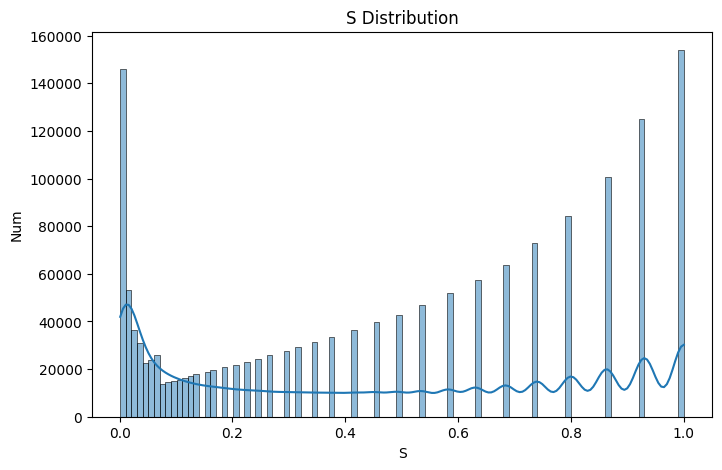

In [30]:
#complex distribution
df_nontrivial = df_moves[df_moves['S'] > 0]

plt.figure(figsize=(8,5))
sns.histplot(df_nontrivial['S'], bins=100, kde=True)
plt.title('S Distribution')
plt.ylabel('Num')
plt.xlabel('S')
plt.show()

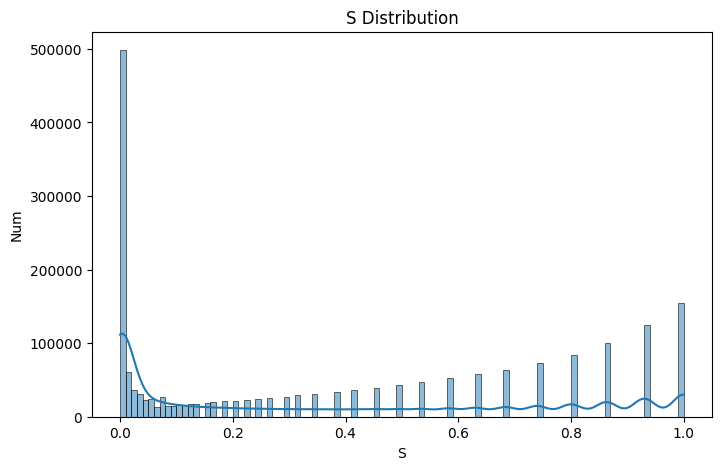

In [31]:
plt.figure(figsize=(8,5))
sns.histplot(df_moves['S'], bins=100, kde=True)
plt.title('S Distribution')
plt.ylabel('Num')
plt.xlabel('S')
plt.show()

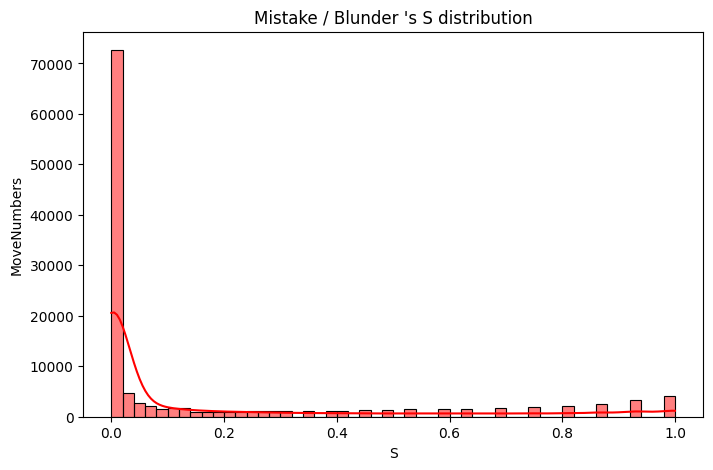

In [ ]:
#mistake blunder distribution
# 只保留错误步
errors_df = df_moves[df_moves['Is_Error']==1]

plt.figure(figsize=(8,5))
sns.histplot(errors_df['S'], bins=50, kde=True, color='red')
plt.title("Mistake / Blunder 's S distribution")
plt.xlabel("Complexity (S)")
plt.ylabel("MoveNumbers")
plt.show()

C:\Users\Administrator\AppData\Local\Temp\ipykernel_31416\2963462960.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('S_bin')['Is_Error']
C:\Users\Administrator\AppData\Local\Temp\ipykernel_31416\2963462960.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='S_bin', y='Is_Error', data=prob_df, palette="Reds")


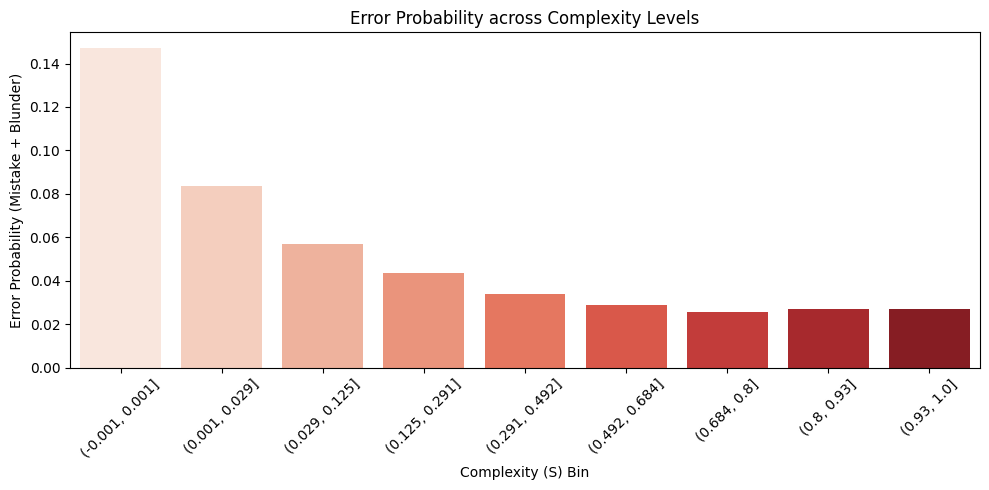

In [ ]:
# Bin complexity into quantiles
df_moves['S_bin'] = pd.qcut(df_moves['S'], 10, duplicates='drop')

# Error probability per bin
prob_df = (
    df_moves
    .groupby('S_bin')['Is_Error']
    .mean()
    .reset_index()
)

plt.figure(figsize=(10,5))
sns.barplot(x='S_bin', y='Is_Error', data=prob_df, palette="Reds")

plt.xticks(rotation=45)
plt.ylabel("Error Probability (Mistake + Blunder)")
plt.xlabel("Complexity (S) Bin")
plt.title("Error Probability across Complexity Levels")

plt.tight_layout()
plt.show()